# Putting many TinyRNNs onto one GPU

Here we investigate a potential speed-up obtained by training many TinyRNNs with the same training data. This means we can run all hyperparameters on the same loop. Could be an upwards of 100x speed up.

In [1]:
%load_ext autoreload

from NM_TinyRNN.code.models import training
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.models import rnns
# write some code to further parallelise the training and test it here
from NM_TinyRNN.code.models import nested_cv as nc
from NM_TinyRNN.code.models import save_data
from NM_TinyRNN.code.models import submit_jobs

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload


CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')



In [241]:

# let's test some code!
test_data_path = DATA_PATH / "bayes_optimal"
test_save_path  = './NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy'
reload(save_data)
reload(ds)
reload(nc)
reload(rnns)
reload(training)

subject_data_path = DATA_PATH/'WS16'
#ws_subject_list = ['WS01','WS02','WS05','WS08','WS09','WS10','WS13','WS14','WS16','WS18','WS20','WS22']
dataset = ds.AB_Dataset(subject_data_path,sequence_length = 64)
input_size = dataset.inputs.shape[-1]
model = rnns.TinyRNN(rnn_type = 'monoGRU',nonlinearity = 'relu', hidden_size = 2,
                     input_size=input_size, input_encoding='unipolar',input_forced_choice = False)

# we use a trainer with ensemble model training across hyperparameters
trainer = training.Trainer(weight_seeds = list(range(1,11)),
                        sparsity_lambdas = [1e-1,1e-2,1e-3,1e-4,1e-5],
                        energy_lambdas = [1e-1,0.01,1e-3],
                        hebbian_lambdas = [0.0],
                        covariance_lambdas = [0.0])
final_state_dict, config, loss_dict = trainer.fit(model, dataset)


Sequence length 64 excludes 7.1% of trials
Parallelizing 150 models on cpu
Data split (session-level): 15 train, 2 validation, and 2 evaluation


  3%|▎         | 320/10000 [02:03<1:02:08,  2.60it/s]

Search complete. Best model index: 129. Val. loss: 0.5138266682624817


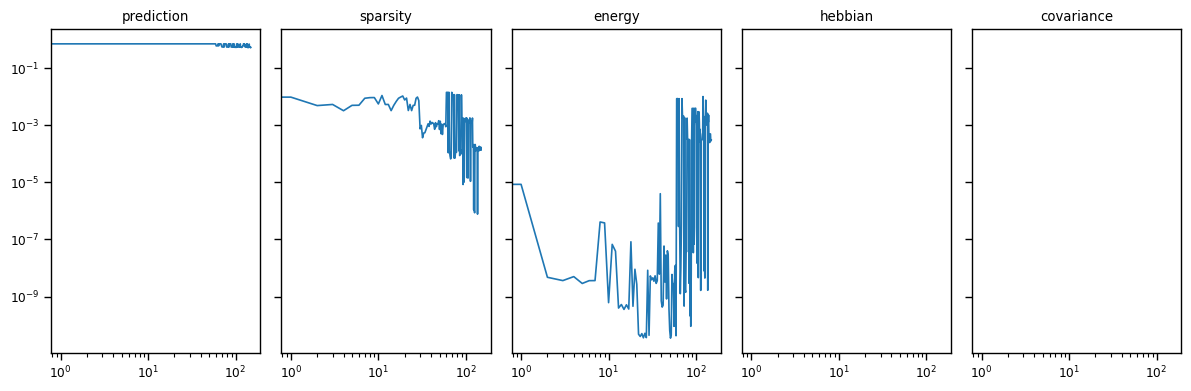

In [242]:
#plot losses
fig, ax = plt.subplots(1,len([x for x in loss_dict.keys()]), sharey=True, figsize=(12,4))
for i, (k,v) in enumerate(loss_dict.items()):
    ax[i].loglog(np.arange(len(v)),v)
    ax[i].set_title(k)
plt.tight_layout()

<Axes: xlabel='logit_value', ylabel='logit_change'>

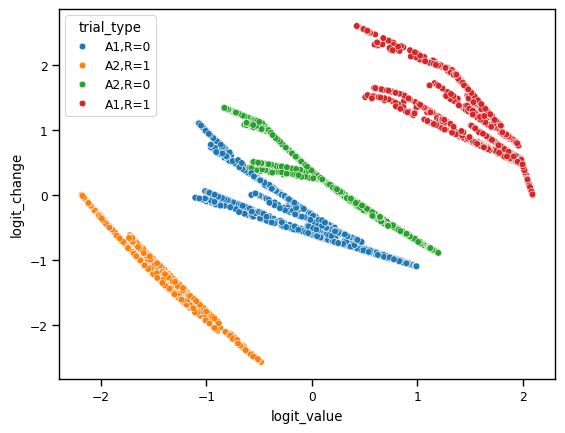

In [247]:
# let's look at a logit plot
model.load_state_dict(final_state_dict)
reload(save_data)
splits = nc.nested_cv_splits(dataset)
trials_df = save_data.get_model_trial_by_trial_df(model, dataset, splits['inner_folds'][0])
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='logit_value', y='logit_change', hue='trial_type')

In [ ]:
#Here we've got code to run all inner loops in parallel,  

outer_results = nc.run_outer_fold(model, dataset,
                                  outer_loop_number = 1,
                                  n_outer_loops = 3,
                                  save_path = test_save_path,
                                  trainer_kwargs = {'weight_seeds':list(range(1,11)),
                                                'sparsity_lambdas':[1e-1,1e-2,1e-3,1e-4,1e-5],
                                                 'energy_lambdas':[1e-1,1e-2,1e-3],
                                                 'hebbian_lambdas':[0.0],
                                                 'covariance_lambdas':[0.0]} )

print([d['val_loss'] for d in outer_results['inner_results']])


[outer 1/3]  outer eval: 352 blocks  |  2 inner folds  |  saving to NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy
Parallelizing 150 models on cpu
Parallelizing 150 models on cpu


  1%|          | 76/10000 [02:07<4:36:48,  1.67s/it]


KeyboardInterrupt: 

## Training on HPC


In [2]:
from NM_TinyRNN.code.models import submit_jobs
reload(submit_jobs)
#we load a dataframe with the subjects we want to train
info_df = submit_jobs.get_ws_all_info_df()
info_df.loc[0,'save_path']


PosixPath('NM_TinyRNN/data/rnns/test_input_encodings/WS_all/GRU/energy')

In [3]:
train_df = info_df.drop_duplicates(['subject_id','model_id',])
train_df

,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,input_encoding,input_forced_choice,nm_size,nm_dim,nm_mode,model_id,save_path,data_path,completed
0,WS_all,1,GRU,1,relu,energy,unipolar,True,1,1,row,1_unit_GRU_relu_unipolar_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
1,WS_all,1,GRU,2,relu,energy,unipolar,True,1,1,row,2_unit_GRU_relu_unipolar_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
2,WS_all,1,GRU,1,relu,energy,unipolar,False,1,1,row,1_unit_GRU_relu_unipolar,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
3,WS_all,1,GRU,2,relu,energy,unipolar,False,1,1,row,2_unit_GRU_relu_unipolar,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
4,WS_all,1,GRU,1,relu,energy,onehot,True,1,1,row,1_unit_GRU_relu_onehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
5,WS_all,1,GRU,2,relu,energy,onehot,True,1,1,row,2_unit_GRU_relu_onehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
6,WS_all,1,GRU,1,relu,energy,onehot,False,1,1,row,1_unit_GRU_relu_onehot,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
7,WS_all,1,GRU,2,relu,energy,onehot,False,1,1,row,2_unit_GRU_relu_onehot,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
8,WS_all,1,GRU,1,relu,energy,actonehot,True,1,1,row,1_unit_GRU_relu_actonehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
9,WS_all,1,GRU,2,relu,energy,actonehot,True,1,1,row,2_unit_GRU_relu_actonehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1


In [202]:
submit_jobs.run_training(test=True)

Submitting model training for WS_all to HPC
Submitted batch job 3003280
Submitting model training for WS_all to HPC
Submitted batch job 3003281
Submitting model training for WS_all to HPC
Submitted batch job 3003282
Submitting model training for WS_all to HPC
Submitted batch job 3003283
Submitting model training for WS_all to HPC
Submitted batch job 3003284
Submitting model training for WS_all to HPC
Submitted batch job 3003285
Submitting model training for WS_all to HPC
Submitted batch job 3003286
Submitting model training for WS_all to HPC
Submitted batch job 3003287
Submitting model training for WS_all to HPC
Submitted batch job 3003288
Submitting model training for WS_all to HPC
Submitted batch job 3003289
Submitting model training for WS_all to HPC
Submitted batch job 3003290
Submitting model training for WS_all to HPC
Submitted batch job 3003291
Submitting model training for WS_all to HPC
Submitted batch job 3003292
Submitting model training for WS_all to HPC
Submitted batch job 

In [5]:
train_df = train_df.drop_duplicates(['subject_id','model_id','input_forced_choice'])
train_df

,subject_id,outer_loop_n,model_type,hidden_size,nonlinearity,constraint,input_encoding,input_forced_choice,nm_size,nm_dim,nm_mode,model_id,save_path,data_path,completed
0,WS_all,1,GRU,1,relu,energy,unipolar,True,1,1,row,1_unit_GRU_relu_unipolar_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
1,WS_all,1,GRU,2,relu,energy,unipolar,True,1,1,row,2_unit_GRU_relu_unipolar_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
2,WS_all,1,GRU,1,relu,energy,unipolar,False,1,1,row,1_unit_GRU_relu_unipolar,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
3,WS_all,1,GRU,2,relu,energy,unipolar,False,1,1,row,2_unit_GRU_relu_unipolar,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
4,WS_all,1,GRU,1,relu,energy,onehot,True,1,1,row,1_unit_GRU_relu_onehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
5,WS_all,1,GRU,2,relu,energy,onehot,True,1,1,row,2_unit_GRU_relu_onehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
6,WS_all,1,GRU,1,relu,energy,onehot,False,1,1,row,1_unit_GRU_relu_onehot,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
7,WS_all,1,GRU,2,relu,energy,onehot,False,1,1,row,2_unit_GRU_relu_onehot,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,0
8,WS_all,1,GRU,1,relu,energy,actonehot,True,1,1,row,1_unit_GRU_relu_actonehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1
9,WS_all,1,GRU,2,relu,energy,actonehot,True,1,1,row,2_unit_GRU_relu_actonehot_forced,NM_TinyRNN/data/rnns/test_input_encodings/WS_a...,NM_TinyRNN/data/AB_behaviour/WS,1


In [7]:
uncompleted = train_df[train_df.completed==False]

uncompleted.model_id.unique()

array(['1_unit_GRU_relu_unipolar', '2_unit_GRU_relu_unipolar',
       '1_unit_GRU_relu_onehot', '2_unit_GRU_relu_onehot',
       '1_unit_GRU_relu_actonehot', '2_unit_GRU_relu_actonehot',
       '1_unit_GRU_tanh_unipolar', '2_unit_GRU_tanh_unipolar',
       '1_unit_GRU_tanh_onehot', '2_unit_GRU_tanh_onehot',
       '1_unit_GRU_tanh_actonehot', '2_unit_GRU_tanh_actonehot',
       '1_unit_monoGRU_relu_unipolar_forced',
       '1_unit_monoGRU_relu_unipolar', '2_unit_monoGRU_relu_unipolar',
       '1_unit_monoGRU_relu_onehot_forced',
       '2_unit_monoGRU_relu_onehot_forced', '1_unit_monoGRU_relu_onehot',
       '2_unit_monoGRU_relu_onehot', '1_unit_monoGRU_relu_actonehot',
       '2_unit_monoGRU_relu_actonehot', '1_unit_monoGRU_tanh_unipolar',
       '2_unit_monoGRU_tanh_unipolar', '1_unit_monoGRU_tanh_onehot',
       '2_unit_monoGRU_tanh_onehot', '1_unit_monoGRU_tanh_actonehot',
       '2_unit_monoGRU_tanh_actonehot'], dtype=object)

In [8]:
for df in uncompleted.itertuples():

    options = rnns.OPTIONS_DICT
    options['rnn_type'] = df.model_type
    options['hidden_size'] = df.hidden_size
    options['nm_size'] = df.nm_size
    options['nm_dim'] = df.nm_dim
    options['nm_mode'] = df.nm_mode
    options['input_encoding'] = df.input_encoding
    options['input_forced_choice'] = df.input_forced_choice
    options['nonlinearity'] = df.nonlinearity

    dataset = ds.AB_Dataset(df.data_path, 
                            input_encoding=df.input_encoding,
                            input_forced_choice=df.input_forced_choice)
    options['input_size'] = dataset.inputs.shape[-1]

    model = rnns.TinyRNN(**options)
    break

model.get_model_id()

Sequence length 64 excludes 7.7% of trials
DEBUG get_model_id: input_encoding = 'unipolar'
DEBUG get_model_id: input_forced_choice = False


'1_unit_GRU_relu_unipolar'

In [13]:
import inspect 
print(inspect.getsource(model.get_model_id))

  def get_model_id(self):
    '''Helper function to save and reinstate model'''
    model_id = f'{self.H}_unit_{self.rnn_type}_{self.nonlinearity}_{self.input_encoding}'
    if self.rnn_type == 'NMRNN':
        model_id=f'{self.H}_unit_{self.rnn_type}_{self.nm_size}_subunits_{self.nm_dim}_{self.nm_mode}_{self.nonlinearity}_{self.input_encoding}'
    if self.input_forced_choice:
       model_id+='_forced'
    print("DEBUG get_model_id: input_encoding =", repr(self.input_encoding))
    print("DEBUG get_model_id: input_forced_choice =", self.input_forced_choice)
    return model_id



In [17]:
#this is essentially a local serialised training loop:
reload(rnns)
reload(nc)
for train_info in uncompleted.itertuples():
    nc.train_outers(f'{train_info.data_path}',
                         f'{train_info.save_path}',
                         f'{train_info.model_type}',
                         int(train_info.hidden_size),
                         int(train_info.nm_size),
                         int(train_info.nm_dim),
                         f'{train_info.nm_mode}',
                         f'{train_info.input_encoding}',
                         train_info.input_forced_choice,
                         f'{train_info.nonlinearity}',
                         f'{train_info.constraint}')
    break

Sequence length 64 excludes 7.7% of trials
model.input_forced_choice False
DEBUG get_model_id: input_encoding = 'unipolar'
DEBUG get_model_id: input_forced_choice = False
DEBUG get_model_id: model_id = 1_unit_GRU_relu_unipolar
model_id: 1_unit_GRU_relu_unipolar
[outer 1/10]  outer eval: 98 blocks  |  9 inner folds  |  saving to NM_TinyRNN/data/rnns/test_input_encodings/WS_all/GRU/energy


KeyboardInterrupt: 

In [18]:
reload(submit_jobs)
submit_jobs.run_training(overwrite = True, test=True)

KeyboardInterrupt: 